# CN112313335A Regime Investigation

This notebook isolates the `CN112313335A` slice and compares it against the rest of the dataset.
The goal is to understand whether this patent looks like a removable data-quality issue or a biologically valid but difficult regime.

## Questions

1. Does `CN112313335A` occupy a very different gene, cell-type, concentration, or time distribution?
2. Is its inhibition distribution shifted relative to the rest of the data?
3. Are the worst errors concentrated in a few sub-regimes inside the patent?
4. Does the patent show signs of systematic underprediction rather than random noise?

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

project_root = Path.cwd().resolve()
while not (project_root / "utils").exists() and project_root != project_root.parent:
    project_root = project_root.parent

if not (project_root / "utils").exists():
    raise RuntimeError("Could not locate project root containing the utils package")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from utils.merge_historic_data import load_merged_dataset
from utils.pipeline import SiRNADataPipeline
from utils.splitter import GroupKFoldLeakPerGroup

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

In [2]:
cmsirna_path = os.environ.get("CMSIRNA_RAW_DATA_PATH")
historic_path = os.environ.get("CMSIRNA_RAW_HISTORIC_DATA_PATH")

assert cmsirna_path, "CMSIRNA_RAW_DATA_PATH is not set"
assert historic_path, "CMSIRNA_RAW_HISTORIC_DATA_PATH is not set"

raw_df = load_merged_dataset(cmsirna_path, historic_path)
pipeline = SiRNADataPipeline(target_len=25, fetch_missing_mrna=True)
enriched_df = pipeline.enrich_dataset_with_encodings(
    raw_df,
    strict_cleaning=True,
    add_mrna=True,
)
X, groups, y = pipeline.prepare_for_classical_ml(
    enriched_df,
    target_column="Inhibition",
    use_normalized_conditions=False,
)

mask = ~np.isnan(y)
X = X[mask]
groups = groups[mask]
y = y[mask]
analysis_df = enriched_df.loc[mask].reset_index(drop=True).copy()

analysis_df["patent_group"] = analysis_df.get(
    "patent_ID", pd.Series(index=analysis_df.index, dtype=object)
).fillna("HISTORIC_OR_UNKNOWN")
analysis_df["Authorization_status"] = analysis_df.get(
    "Authorization_status", pd.Series(index=analysis_df.index, dtype=object)
).fillna("UNKNOWN")

print("Analysis dataframe shape:", analysis_df.shape)
print("Unique genes:", len(np.unique(groups)))

loaded 3515 historic rows
merged 43153 CMsiRNA and 3515 historic rows into 46668
Running qc and data cleaning
dropped 4233 rows for in-vivo readings
dropped 565 rows for mM readings
dropped 115 rows for unknown or unwanted cell lines
dropped 47 rows for out-of-range inhibition
dropped 1749 rows for missing or unknown concentration
dropped 796 rows for concentration > 200 nM
filled 7522 rows for missing time of administration
dropped 2198 rows with a missing or >25 nt strand
dropped 6 columns: ['Modification_locations_Sense_strand', 'Modification_locations_Antisense_strand', 'Modifications_sense_strand', 'Modifications_AntiSense_strand_3_5', 'position_Antisense_strand', 'position_Sense_strand']
Mapping mRNA structural profiles
Error reading reference dataset: [Errno 2] No such file or directory: '/home/larsena8/software/fennec/src/fennec/support_files/train_data_v1.1.0_N=27742.csv'
Loaded 47 gene sequences from local cache
Loaded 0 gene sequences from reference CSV
Building gene -> mRNA

In [3]:
frozen_params = {
    "n_estimators": 800,
    "max_depth": 4,
    "learning_rate": 0.15881823130907038,
    "subsample": 0.8812898741586134,
    "colsample_bytree": 0.7824379872752019,
    "min_child_weight": 4,
    "reg_lambda": 0.8342807691178866,
    "reg_alpha": 1.4296995092035882,
    "gamma": 0.07531958697602548,
}

gene_cv = GroupKFoldLeakPerGroup(n_splits=3, leak_n=0, random_state=42)
oof_frames = []

for fold_id, (train_idx, test_idx) in enumerate(gene_cv.split(X, y, groups), start=1):
    model = XGBRegressor(tree_method="hist", n_jobs=-1, random_state=42, **frozen_params)
    model.fit(X[train_idx], y[train_idx])
    fold_pred = model.predict(X[test_idx])

    fold_frame = analysis_df.iloc[test_idx].reset_index().rename(columns={"index": "source_index"}).copy()
    fold_frame["row_index"] = test_idx
    fold_frame["fold_id"] = fold_id
    fold_frame["group"] = groups[test_idx]
    fold_frame["y_true"] = y[test_idx]
    fold_frame["y_pred"] = fold_pred
    fold_frame["residual"] = fold_frame["y_true"] - fold_frame["y_pred"]
    fold_frame["abs_error"] = fold_frame["residual"].abs()
    oof_frames.append(fold_frame)

predictions_df = pd.concat(oof_frames, ignore_index=True)
predictions_df["is_cn112313335a"] = predictions_df["patent_group"].eq("CN112313335A")
predictions_df["prediction_bias"] = predictions_df["y_pred"] - predictions_df["y_true"]

predictions_df.head()

,source_index,ID,patent_ID,Authorization_status,Accession_number,gene_target_symbol_name,Gene_ID,The_name_of_double_helix,Antisense_seqence,length_anti_sense_strand,Modifications_AntiSense_strand,Modification_Types_Antisense_strand,Sense_seqence,length_sense_strand,Modification_Types_Sense_strand,Inhibition,SD,Cell_Type,Concentration,Time_of_administration,Title,mRNA,Concentration_nM,Time_of_administration_h,mRNA_five_prime,mRNA_three_prime,edit_distance,target_site_pct,Sense_Sequence_One_Hot,Antisense_Sequence_One_Hot,Sense_Acid_One_Hot,Sense_Sugar_One_Hot,Sense_Linker_One_Hot,Antisense_Acid_One_Hot,Antisense_Sugar_One_Hot,Antisense_Linker_One_Hot,Cell_Type_One_Hot,Concentration_log10_nM,Concentration_norm,Time_norm,patent_group,row_index,fold_id,group,y_true,y_pred,residual,abs_error,is_cn112313335a,prediction_bias
0,4680,004-03-02-01275-1n-XXX--1.20,CN108368506A,Substantive Examination,NM_005577.4,LPA,4018.0,AD00571,TCGGCAGUCCCUUCUGCGUTT,21.0,dTCfgGfcAfgUfcCfcUfuCfuGfcGfudTsdT,1*2'-Deoxy thymidine || 2*2'-Fluorocytidine ||...,ACGCAGAAGGGACUGCCGAT,20.0,1*2'-Fluoroadenosine || 2*2'-O-Methylcytidine ...,-1.2,14.6,Hep3B,1.0,24.0,用于抑制LPA的基因表达的组合物和方法,GUAAGUCAACAAUGUCCUGGGAUUGGGACACACUUUCUGGGCACUG...,1.0,24.0,GUAAGUCAACAAUGUCCUGGGAUUGGGACACACUUUCUGGGCACUG...,UUGGACGGGAGACAGAGUGAAGCAUCAACCUACUUAGAAGCUGAAA...,2.0,0.058778,"[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0....","[[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0], [0.0, 0....","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]...","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[[0.0, 1.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]...","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ...",0.0,0.620954,0.121951,CN108368506A,4680,1,LPA,-1.2,34.769035,-35.969035,35.969035,False,35.969035
1,4681,004-03-02-01276-1n-XXX-22.40,CN108368506A,Substantive Examination,NM_005577.4,LPA,4018.0,AD00572,TGUAGCACUCCUGCACCCCTT,21.0,dTGfuAfgCfaCfuCfcUfgCfaCfcCfcdTsdT,1*2'-Deoxy thymidine || 2*2'-Fluoroguanosine |...,GGGGUGCAGGAGUGCUACAT,20.0,1*2'-Fluoroguanosine || 2*2'-O-Methylguanosine...,22.4,6.2,Hep3B,1.0,24.0,用于抑制LPA的基因表达的组合物和方法,GUAAGUCAACAAUGUCCUGGGAUUGGGACACACUUUCUGGGCACUG...,1.0,24.0,GUAAGUCAACAAUGUCCUGGGAUUGGGACACACUUUCUGGGCACUG...,UUGGACGGGAGACAGAGUGAAGCAUCAACCUACUUAGAAGCUGAAA...,3.0,0.073084,"[[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0....","[[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0], [0.0, 0....","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]...","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[[0.0, 1.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]...","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ...",0.0,0.620954,0.121951,CN108368506A,4681,1,LPA,22.4,0.201030,22.198970,22.198970,False,-22.198970
2,4682,004-03-02-01277-1n-XXX-29.20,CN108368506A,Substantive Examination,NM_005577.4,LPA,4018.0,AD00573,TAAUAAGGGGCUGCCACAGTT,21.0,dTAfaUfaAfgGfgGfcUfgCfcAfcAfgdTsdT,1*2'-Deoxy thymidine || 2*2'-Fluoroadenosine |...,CUGUGGCAGCCCCUUAUUAT,20.0,1*2'-Fluorocytidine || 2*2'-O-Methyluridine ||...,29.2,5.4,Hep3B,1.0,24.0,用于抑制LPA的基因表达的组合物和方法,GUAAGUCAACAAUGUCCUGGGAUUGGGACACACUUUCUGGGCACUG...,1.0,24.0,GUAAGUCAACAAUGUCCUGGGAUUGGGACACACUUUCUGGGCACUG...,UUGGACGGGAGACAGAGUGAAGCAUCAACCUACUUAGAAGCUGAAA...,3.0,0.419219,"[[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0], [0.0, 1....","[[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0], [1.0, 0....","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]...","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[[0.0, 1.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]...","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ...",0.0,0.620954,0.121951,CN108368506A,4682,1,LPA,2

In [4]:
def summarize_slice(df):
    return pd.Series({
        "n_samples": len(df),
        "n_genes": df["group"].nunique(),
        "n_cell_types": df["Cell_Type"].nunique(),
        "n_concentrations": df["Concentration_nM"].nunique(),
        "n_times": df["Time_of_administration_h"].nunique(),
        "spearman": float(spearmanr(df["y_true"], df["y_pred"], nan_policy="omit").statistic),
        "mae": float(mean_absolute_error(df["y_true"], df["y_pred"])),
        "rmse": float(mean_squared_error(df["y_true"], df["y_pred"]) ** 0.5),
        "mean_true": float(df["y_true"].mean()),
        "mean_pred": float(df["y_pred"].mean()),
        "mean_bias": float((df["y_pred"] - df["y_true"]).mean()),
    })

slice_summary = pd.DataFrame({
    "CN112313335A": summarize_slice(predictions_df.loc[predictions_df["is_cn112313335a"]]),
    "Rest of dataset": summarize_slice(predictions_df.loc[~predictions_df["is_cn112313335a"]]),
}).T
slice_summary

,n_samples,n_genes,n_cell_types,n_concentrations,n_times,spearman,mae,rmse,mean_true,mean_pred,mean_bias
CN112313335A,366.0,1.0,1.0,2.0,1.0,-0.809342,73.222705,75.538043,95.782978,22.560272,-73.222705
Rest of dataset,35078.0,54.0,21.0,62.0,6.0,0.398391,26.097727,32.969711,42.492708,41.305782,-1.186922


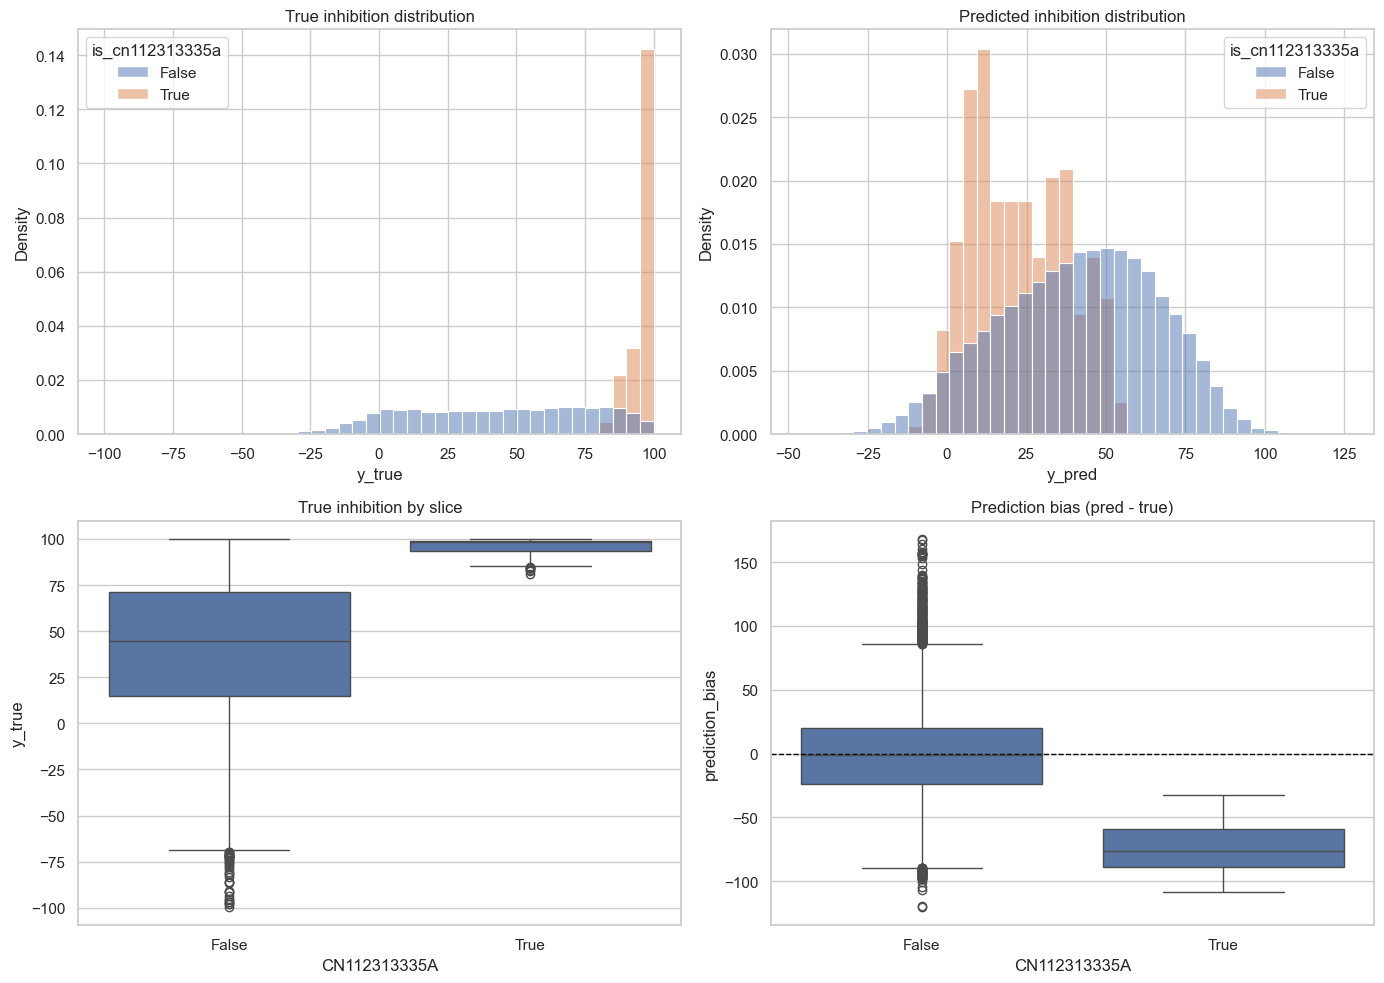

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(
    data=predictions_df,
    x="y_true",
    hue="is_cn112313335a",
    stat="density",
    common_norm=False,
    bins=40,
    ax=axes[0, 0],
)
axes[0, 0].set_title("True inhibition distribution")

sns.histplot(
    data=predictions_df,
    x="y_pred",
    hue="is_cn112313335a",
    stat="density",
    common_norm=False,
    bins=40,
    ax=axes[0, 1],
)
axes[0, 1].set_title("Predicted inhibition distribution")

sns.boxplot(data=predictions_df, x="is_cn112313335a", y="y_true", ax=axes[1, 0])
axes[1, 0].set_title("True inhibition by slice")
axes[1, 0].set_xlabel("CN112313335A")

sns.boxplot(data=predictions_df, x="is_cn112313335a", y="prediction_bias", ax=axes[1, 1])
axes[1, 1].axhline(0, linestyle="--", color="black", linewidth=1)
axes[1, 1].set_title("Prediction bias (pred - true)")
axes[1, 1].set_xlabel("CN112313335A")

plt.tight_layout()

In [6]:
def top_share_table(df, column, top_n=10):
    counts = df[column].fillna("MISSING").value_counts().head(top_n)
    out = counts.rename_axis(column).reset_index(name="n_samples")
    out["pct_within_slice"] = out["n_samples"] / len(df)
    return out

cn_df = predictions_df.loc[predictions_df["is_cn112313335a"]].copy()
rest_df = predictions_df.loc[~predictions_df["is_cn112313335a"]].copy()

print("Top genes in CN112313335A")
display(top_share_table(cn_df, "group", top_n=10))

print("Top cell types in CN112313335A")
display(top_share_table(cn_df, "Cell_Type", top_n=10))

print("Top concentrations in CN112313335A")
display(top_share_table(cn_df, "Concentration_nM", top_n=10))

print("Top times in CN112313335A")
display(top_share_table(cn_df, "Time_of_administration_h", top_n=10))

Top genes in CN112313335A


,group,n_samples,pct_within_slice
0,AGT,366,1.0


Top cell types in CN112313335A


,Cell_Type,n_samples,pct_within_slice
0,Hep3B,366,1.0


Top concentrations in CN112313335A


,Concentration_nM,n_samples,pct_within_slice
0,0.1,184,0.502732
1,10.0,182,0.497268


Top times in CN112313335A


,Time_of_administration_h,n_samples,pct_within_slice
0,24.0,366,1.0


In [7]:
def contrast_table(df, column, min_count=20, top_n=20):
    tmp = (
        df.assign(key=df[column].fillna("MISSING"))
        .groupby(["is_cn112313335a", "key"])
        .size()
        .rename("n_samples")
        .reset_index()
    )
    pivot = tmp.pivot(index="key", columns="is_cn112313335a", values="n_samples").fillna(0)
    pivot.columns = ["rest_n", "cn_n"]
    pivot = pivot.reset_index().rename(columns={"key": column})
    pivot = pivot[(pivot["cn_n"] + pivot["rest_n"]) >= min_count].copy()
    pivot["cn_pct"] = pivot["cn_n"] / max(len(cn_df), 1)
    pivot["rest_pct"] = pivot["rest_n"] / max(len(rest_df), 1)
    pivot["pct_gap"] = pivot["cn_pct"] - pivot["rest_pct"]
    return pivot.sort_values("pct_gap", ascending=False).head(top_n)

print("Most overrepresented genes in CN112313335A")
display(contrast_table(predictions_df, "group", min_count=20, top_n=15))

print("Most overrepresented cell types in CN112313335A")
display(contrast_table(predictions_df, "Cell_Type", min_count=20, top_n=15))

print("Most overrepresented concentrations in CN112313335A")
display(contrast_table(predictions_df, "Concentration_nM", min_count=20, top_n=15))

print("Most overrepresented times in CN112313335A")
display(contrast_table(predictions_df, "Time_of_administration_h", min_count=20, top_n=15))

Most overrepresented genes in CN112313335A


,group,rest_n,cn_n,cn_pct,rest_pct,pct_gap
0,AGT,4372.0,366.0,1.0,0.124637,0.875363
13,GAPDH,20.0,0.0,0.0,0.000570,-0.000570
35,SEAP,21.0,0.0,0.0,0.000599,-0.000599
23,MMAC1,36.0,0.0,0.0,0.001026,-0.001026
17,ICAM-1,40.0,0.0,0.0,0.001140,-0.001140
19,LAMIN A,44.0,0.0,0.0,0.001254,-0.001254
4,CACNB1,46.0,0.0,0.0,0.001311,-0.001311
46,UBE2J1,49.0,0.0,0.0,0.001397,-0.001397
47,UBE2L3,53.0,0.0,0.0,0.001511,-0.001511
5,CDC34,57.0,0.0,0.0,0.001625,-0.001625


Most overrepresented cell types in CN112313335A


,Cell_Type,rest_n,cn_n,cn_pct,rest_pct,pct_gap
7,Hep3B,11601.0,366.0,1.0,0.330720,0.669280
16,Primary Macaque Hepatocytes,22.0,0.0,0.0,0.000627,-0.000627
20,T24 Cells,76.0,0.0,0.0,0.002167,-0.002167
9,Hepa1-6,139.0,0.0,0.0,0.003963,-0.003963
14,Non-human hepatocytes,190.0,0.0,0.0,0.005417,-0.005417
11,Human iPSC-derived cortical neurons,205.0,0.0,0.0,0.005844,-0.005844
3,HEK293 Cells,260.0,0.0,0.0,0.007412,-0.007412
18,Primary mouse hepatocytes,316.0,0.0,0.0,0.009008,-0.009008
13,Neuro2A cell line,382.0,0.0,0.0,0.010890,-0.010890
5,HeLa Cells,783.0,0.0,0.0,0.022322,-0.022322


Most overrepresented concentrations in CN112313335A


,Concentration_nM,rest_n,cn_n,cn_pct,rest_pct,pct_gap
25,0.1000,7299.0,184.0,0.502732,0.208079,0.294653
51,10.0000,9654.0,182.0,0.497268,0.275215,0.222053
54,25.0000,22.0,0.0,0.000000,0.000627,-0.000627
35,0.6000,35.0,0.0,0.000000,0.000998,-0.000998
52,15.0000,35.0,0.0,0.000000,0.000998,-0.000998
44,3.0000,35.0,0.0,0.000000,0.000998,-0.000998
1,0.0003,40.0,0.0,0.000000,0.001140,-0.001140
16,0.0200,41.0,0.0,0.000000,0.001169,-0.001169
50,8.0000,46.0,0.0,0.000000,0.001311,-0.001311
43,2.2222,49.0,0.0,0.000000,0.001397,-0.001397


Most overrepresented times in CN112313335A


,Time_of_administration_h,rest_n,cn_n,cn_pct,rest_pct,pct_gap
1,24.0,24039.0,366.0,1.0,0.685301,0.314699
0,4.0,76.0,0.0,0.0,0.002167,-0.002167
2,40.0,197.0,0.0,0.0,0.005616,-0.005616
5,168.0,205.0,0.0,0.0,0.005844,-0.005844
4,72.0,1404.0,0.0,0.0,0.040025,-0.040025
3,48.0,9157.0,0.0,0.0,0.261047,-0.261047


In [8]:
def grouped_hotspots(df, group_cols, min_samples=20):
    rows = []
    for keys, group_df in df.groupby(group_cols, dropna=False):
        if len(group_df) < min_samples:
            continue
        if not isinstance(keys, tuple):
            keys = (keys,)
        row = {col: value for col, value in zip(group_cols, keys)}
        row.update({
            "n_samples": len(group_df),
            "spearman": float(spearmanr(group_df["y_true"], group_df["y_pred"], nan_policy="omit").statistic),
            "mae": float(group_df["abs_error"].mean()),
            "mean_true": float(group_df["y_true"].mean()),
            "mean_pred": float(group_df["y_pred"].mean()),
            "mean_bias": float(group_df["prediction_bias"].mean()),
        })
        rows.append(row)
    return pd.DataFrame(rows).sort_values(["spearman", "mae"], ascending=[True, False]).reset_index(drop=True)

cn_gene_conc = grouped_hotspots(cn_df, ["group", "Concentration_nM"], min_samples=20)
cn_cell_conc = grouped_hotspots(cn_df, ["Cell_Type", "Concentration_nM"], min_samples=20)

print("Worst gene + concentration combinations within CN112313335A")
display(cn_gene_conc.head(20))

print("Worst cell type + concentration combinations within CN112313335A")
display(cn_cell_conc.head(20))

Worst gene + concentration combinations within CN112313335A


,group,Concentration_nM,n_samples,spearman,mae,mean_true,mean_pred,mean_bias
0,AGT,10.0,182,-0.502275,57.558380,92.877308,35.318928,-57.558380
1,AGT,0.1,184,-0.460491,88.716766,98.657065,9.940299,-88.716766


Worst cell type + concentration combinations within CN112313335A


,Cell_Type,Concentration_nM,n_samples,spearman,mae,mean_true,mean_pred,mean_bias
0,Hep3B,10.0,182,-0.502275,57.558380,92.877308,35.318928,-57.558380
1,Hep3B,0.1,184,-0.460491,88.716766,98.657065,9.940299,-88.716766


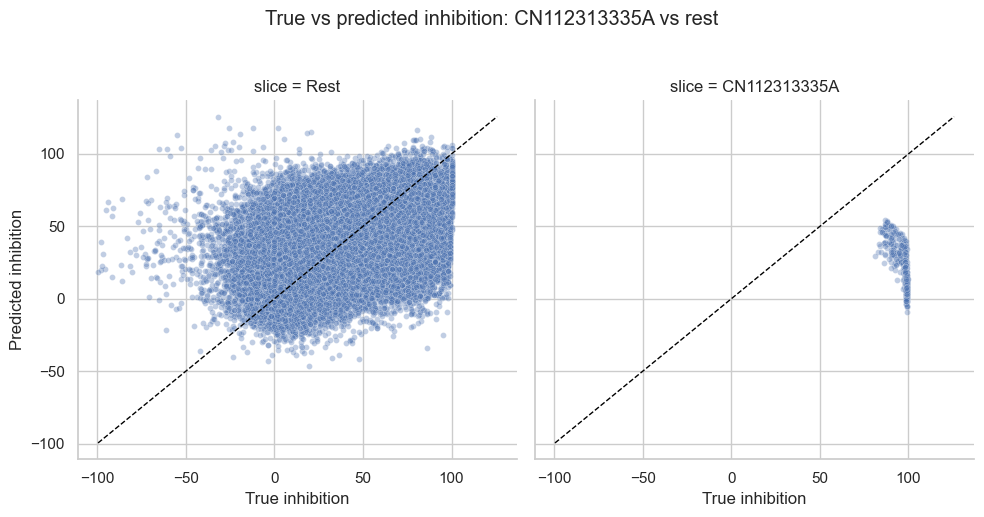

In [9]:
plot_df = predictions_df.copy()
plot_df["slice"] = np.where(plot_df["is_cn112313335a"], "CN112313335A", "Rest")

g = sns.FacetGrid(plot_df, col="slice", height=5, sharex=True, sharey=True)
g.map_dataframe(sns.scatterplot, x="y_true", y="y_pred", alpha=0.35, s=18)

for ax in g.axes.flat:
    lims = [
        min(plot_df["y_true"].min(), plot_df["y_pred"].min()),
        max(plot_df["y_true"].max(), plot_df["y_pred"].max()),
    ]
    ax.plot(lims, lims, linestyle="--", color="black", linewidth=1)
    ax.set_xlabel("True inhibition")
    ax.set_ylabel("Predicted inhibition")

g.fig.suptitle("True vs predicted inhibition: CN112313335A vs rest", y=1.03)
plt.tight_layout()

## Decision Guide

Use the outputs above to decide whether `CN112313335A` is:

- a likely data-quality problem: narrow regime, conflicting behavior, unstable labels, or extreme mismatch to the rest of the data
- a valid but difficult regime: coherent internal structure, strong biological specificity, and systematic underperformance without obvious corruption
- a candidate ablation slice: worth excluding in a comparison run, but not automatically removable from the final training set

Conclusion: 

the AGT + Hep3B + very high inhibition + {0.1, 10 nM} regime is a severe failure mode
